In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Hospital merger dataset available at https://github.com/hyesunghaceoh/strategichospmergerdata/tree/main
hospital_merger_df = pd.read_csv("strategic_ma_db_v2/strategic_ma_db_v2.csv")

# Cost Report dataset downloaded from https://www.cms.gov/data-research/statistics-trends-and-reports/cost-reports/cost-reports-fiscal-year
hcris_df = pd.read_csv("hcris_data/hcris_combined.csv")

In [2]:
print("Merger dataset shape:", hospital_merger_df.shape)
print("HCRIS dataset shape: ", hcris_df.shape)
print("\nMerger columns:", list(hospital_merger_df.columns))
print("HCRIS columns: ", list(hcris_df.columns))

Merger dataset shape: (560269, 17)
HCRIS dataset shape:  (55805, 16)

Merger columns: ['fac_name', 'year', 'medicare_ccn_str', 'year_qtr', 'medicare_ccn', 'hrrcode', 'month', 'source_completed', 'bankruptcy', 'system_exit', 'system_split', 'merger_of_equals', 'target', 'notes', 'system_id', 'system_id_qtr', 'system_id_yr']
HCRIS columns:  ['fiscal_year', 'RPT_REC_NUM', 'PRVDR_NUM', 'NPI', 'FY_BGN_DT', 'FY_END_DT', 'PRVDR_CTRL_TYPE_CD', 'total_operating_costs', 'net_patient_revenue', 'total_charges', 'medicare_charges', 'medicare_payments', 'medicaid_charges', 'medicaid_payments', 'total_discharges', 'cost_per_discharge']


In [3]:
# ensuring consistency across datasets for the CCN, which is used as the hospital identfier and will be used to merge the datasets
def clean_ccn(series):
    """Zero-pad CCN to 6 characters, stripping whitespace and decimals."""
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)  # remove trailing .0 from numeric reads
        .str.zfill(6)  # left-pad with zeros to length 6
    )


hospital_merger_df["ccn"] = clean_ccn(hospital_merger_df["medicare_ccn_str"])
hcris_df["ccn"] = clean_ccn(hcris_df["PRVDR_NUM"])

print("Sample CCNs from merger dataset:", hospital_merger_df["ccn"].head(5).tolist())
print("Sample CCNs from HCRIS dataset: ", hcris_df["ccn"].head(5).tolist())

Sample CCNs from merger dataset: ['200021', '200021', '200021', '200021', '200021']
Sample CCNs from HCRIS dataset:  ['271326', '013025', '103037', '103042', '141990']


In [4]:
# hospital merger dataset is broken up by hospital and financial quarter, here we combine into hospital and calendar year
hospital_merger_df["obs_year"] = (
    hospital_merger_df["year_qtr"].astype(str).str[:4].astype(int)
)

merger_annual = (
    hospital_merger_df.groupby(["ccn", "obs_year"])
    .agg(
        fac_name=("fac_name", "first"),
        hrrcode=("hrrcode", "first"),
        merger_target=("target", "max"),
        merger_of_equals=("merger_of_equals", "max"),
        bankruptcy=("bankruptcy", "max"),
        system_exit=("system_exit", "max"),
        system_split=("system_split", "max"),
        system_id_yr=("system_id_yr", "last"),
    )
    .reset_index()
)

# combined flag: any acquisition or merger of equals this year
merger_annual["any_merger"] = (
    (merger_annual["merger_target"] == 1) | (merger_annual["merger_of_equals"] == 1)
).astype(int)

print(f"\nAnnual merger dataset: {merger_annual.shape[0]:,} hospital-year rows")
print(
    f"Years covered: {merger_annual['obs_year'].min()} – {merger_annual['obs_year'].max()}"
)
print(f"Unique hospitals: {merger_annual['ccn'].nunique():,}")
print(f"Total merger events: {merger_annual['any_merger'].sum():,}")


Annual merger dataset: 46,675 hospital-year rows
Years covered: 2010 – 2019
Unique hospitals: 5,062
Total merger events: 1,523


In [5]:
merged_df = hcris_df.merge(
    merger_annual,
    left_on=["ccn", "fiscal_year"],
    right_on=["ccn", "obs_year"],
    how="left",
)

merged_df = merged_df.drop(columns=["obs_year"], errors="ignore")

merger_flag_cols = [
    "merger_target",
    "merger_of_equals",
    "any_merger",
    "bankruptcy",
    "system_exit",
    "system_split",
]
merged_df[merger_flag_cols] = merged_df[merger_flag_cols].fillna(0).astype(int)

print(f"\nMerged dataset shape: {merged_df.shape}")
print(f"Hospital-years with any merger event: {merged_df['any_merger'].sum():,}")
print(
    f"Hospital-years in HCRIS but not in merger data: {merged_df['fac_name'].isna().sum():,}"
)


Merged dataset shape: (55805, 26)
Hospital-years with any merger event: 1,692
Hospital-years in HCRIS but not in merger data: 13,656


In [6]:
# ── Create Event-Study Variables ──────────────────────────────────────
#
# For difference-in-differences or event study designs you need:
#   treated      — was this hospital ever involved in a merger?
#   merger_year  — the first year this hospital had a merger event
#   years_to_merger — calendar distance from the merger (negative = pre,
#                     0 = merger year, positive = post)
#   post_merger  — simple before/after indicator for DiD

# Find each hospital's first merger year
first_merger_year = (
    merged_df[merged_df["any_merger"] == 1]
    .groupby("ccn")["fiscal_year"]
    .min()
    .rename("merger_year")
    .reset_index()
)

merged_df = merged_df.merge(first_merger_year, on="ccn", how="left")

merged_df["treated"] = merged_df["merger_year"].notna().astype(int)

merged_df["years_to_merger"] = merged_df["fiscal_year"] - merged_df["merger_year"]

merged_df["post_merger"] = (
    (merged_df["treated"] == 1) & (merged_df["years_to_merger"] >= 0)
).astype(int)

print(
    f"\nTreated hospitals (ever merged): {merged_df[merged_df['treated']==1]['ccn'].nunique():,}"
)
print(
    f"Control hospitals (never merged): {merged_df[merged_df['treated']==0]['ccn'].nunique():,}"
)


Treated hospitals (ever merged): 1,242
Control hospitals (never merged): 5,468


In [7]:
print("\n--- cost_per_discharge Distribution ---")
cpd = merged_df["cost_per_discharge"].dropna()
print(f"  Non-null:      {len(cpd):,}")
print(f"  Median:        ${cpd.median():,.0f}")
print(f"  Mean:          ${cpd.mean():,.0f}")
print(f"  Below $1,000:  {(cpd < 1_000).sum():,}  ← likely data errors")
print(f"  Above $500k:   {(cpd > 500_000).sum():,}  ← likely outliers")


--- cost_per_discharge Distribution ---
  Non-null:      53,421
  Median:        $28,005
  Mean:          $78,177
  Below $1,000:  112  ← likely data errors
  Above $500k:   502  ← likely outliers


In [8]:
# remove outliers
# OUTLIER_MIN_CPD = 1_000
# OUTLIER_MAX_CPD = 500_000
# n_before = len(merged_df)
# merged_df = merged_df[
#     merged_df["cost_per_discharge"].isna()
#     | (merged_df["cost_per_discharge"].between(OUTLIER_MIN_CPD, OUTLIER_MAX_CPD))
# ]
# print(f"Dropped {n_before - len(merged_df):,} rows with implausible cost_per_discharge")

In [9]:
n_merged = merged_df[merged_df["treated"] == 1]["ccn"].nunique()
n_not_merged = merged_df[merged_df["treated"] == 0]["ccn"].nunique()
n_total = merged_df["ccn"].nunique()

print("\n--- Hospital Counts ---")
print(f"  Hospitals that experienced a merger:         {n_merged:,}")
print(f"  Hospitals that did not experience a merger:  {n_not_merged:,}")
print(f"  Total hospitals in final dataset:            {n_total:,}")


--- Hospital Counts ---
  Hospitals that experienced a merger:         1,242
  Hospitals that did not experience a merger:  5,468
  Total hospitals in final dataset:            6,710


In [10]:
# count the number of merger events per hospital
merger_counts = (
    merged_df[merged_df["any_merger"] == 1]
    .groupby("ccn")["any_merger"]
    .sum()
    .rename("n_merger_events")
    .reset_index()
)

n_multiple_mergers = (merger_counts["n_merger_events"] > 1).sum()
n_one_merger = (merger_counts["n_merger_events"] == 1).sum()

print(f"Hospitals with exactly one merger:      {n_one_merger:,}")
print(f"Hospitals with more than one merger:    {n_multiple_mergers:,}")
print(f"\nBreakdown by number of merger events:")
print(
    merger_counts["n_merger_events"]
    .value_counts()
    .sort_index()
    .rename("hospitals")
    .to_string()
)

Hospitals with exactly one merger:      893
Hospitals with more than one merger:    349

Breakdown by number of merger events:
n_merger_events
1    893
2    265
3     69
4     14
6      1


In [11]:
merged_df.columns

Index(['fiscal_year', 'RPT_REC_NUM', 'PRVDR_NUM', 'NPI', 'FY_BGN_DT',
       'FY_END_DT', 'PRVDR_CTRL_TYPE_CD', 'total_operating_costs',
       'net_patient_revenue', 'total_charges', 'medicare_charges',
       'medicare_payments', 'medicaid_charges', 'medicaid_payments',
       'total_discharges', 'cost_per_discharge', 'ccn', 'fac_name', 'hrrcode',
       'merger_target', 'merger_of_equals', 'bankruptcy', 'system_exit',
       'system_split', 'system_id_yr', 'any_merger', 'merger_year', 'treated',
       'years_to_merger', 'post_merger'],
      dtype='object')

In [14]:
# do not include likely outliers or errors in EDA
plot_df = merged_df[merged_df["cost_per_discharge"].between(1_000, 500_000)].copy()
plot_df["group"] = plot_df["treated"].map(
    {1: "Treated (merged)", 0: "Control (never merged)"}
)

cols = [
    "cost_per_discharge",
    "total_operating_costs",
    "net_patient_revenue",
    "total_charges",
    "total_discharges",
    "medicare_charges",
    "medicare_payments",
    "medicaid_charges",
    "medicaid_payments",
]

summary = (
    merged_df[cols]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T.rename(columns={"50%": "median", "25%": "p25", "75%": "p75"})[
        ["count", "mean", "median", "std", "min", "p25", "p75", "max"]
    ]
    .round(0)
)
print(summary.to_string())

print("\n--- cost_per_discharge by Group ---")
print(
    plot_df.groupby("group")["cost_per_discharge"]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .round(0)
    .to_string()
)

print("\n--- Missing Values ---")
missing = merged_df[cols + ["treated", "post_merger", "years_to_merger"]].isna().sum()
missing_pct = (missing / len(merged_df) * 100).round(1)
print(pd.DataFrame({"missing_n": missing, "missing_%": missing_pct}).to_string())

                         count         mean      median          std           min         p25          p75           max
cost_per_discharge     53421.0      78177.0     28005.0     802908.0 -7.269870e+05     19026.0      45650.0  7.516912e+07
total_operating_costs  53528.0  153426614.0  47105276.0  296255704.0 -1.305022e+09  17429254.0  164968694.0  6.418542e+09
net_patient_revenue    55084.0  154228145.0  48499692.0  301479384.0 -1.057356e+08  18393701.0  162770157.0  6.444113e+09
total_charges          55070.0      67113.0     23725.0    4679146.0  6.000000e+00      9125.0      61488.0  1.098011e+09
total_discharges       54999.0       5542.0      1702.0       8710.0  1.000000e+00       468.0       7198.0  1.368330e+05
medicare_charges       12094.0      35802.0     24698.0      34632.0  0.000000e+00     10728.0      50350.0  4.157260e+05
medicare_payments      30738.0    2448567.0   1611154.0    2570537.0  5.920000e+02    620182.0    3462406.0  3.008747e+07
medicaid_charges       5

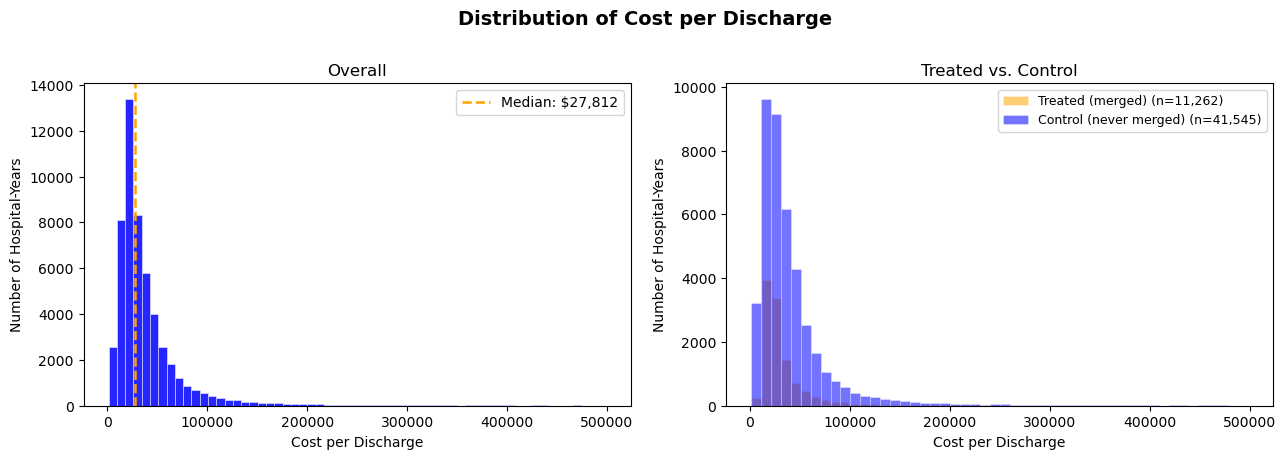

Saved: eda_01_cpd_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(
    "Distribution of Cost per Discharge", fontsize=14, fontweight="bold", y=1.01
)

ax = axes[0]
ax.hist(
    plot_df["cost_per_discharge"],
    bins=60,
    color="blue",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.4,
)
ax.set_xlabel("Cost per Discharge")
ax.set_ylabel("Number of Hospital-Years")
ax.set_title("Overall")
ax.legend()

ax = axes[1]
for label, color in [
    ("Treated (merged)", "orange"),
    ("Control (never merged)", "blue"),
]:
    subset = plot_df[plot_df["group"] == label]["cost_per_discharge"]
    ax.hist(
        subset,
        bins=50,
        alpha=0.55,
        color=color,
        edgecolor="white",
        linewidth=0.4,
        label=f"{label} (n={len(subset):,})",
    )
ax.set_xlabel("Cost per Discharge")
ax.set_ylabel("Number of Hospital-Years")
ax.set_title("Treated vs. Control")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

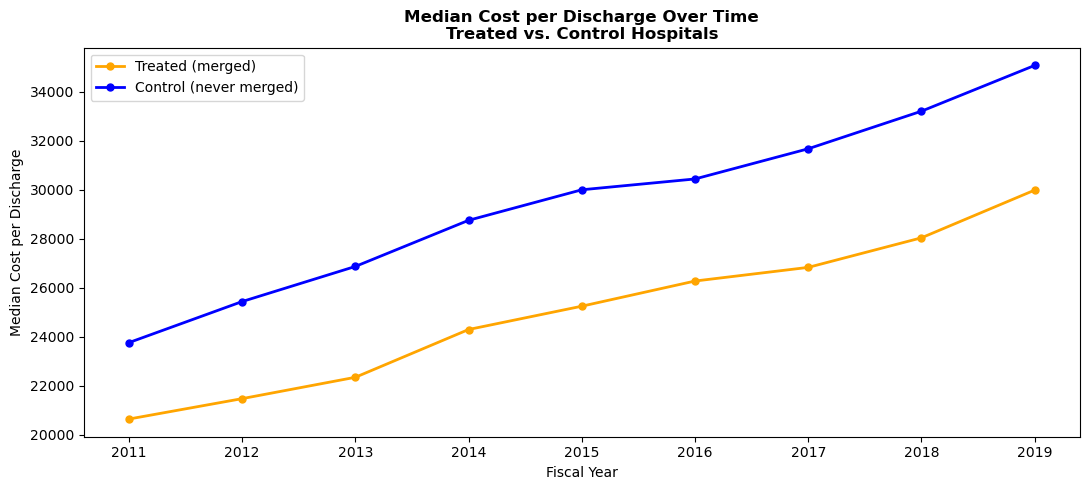

Saved: eda_02_cpd_time_trend.png


In [ ]:
time_trend = (
    plot_df.groupby(["fiscal_year", "group"])["cost_per_discharge"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
for label, color in [
    ("Treated (merged)", "orange"),
    ("Control (never merged)", "blue"),
]:
    sub = time_trend[time_trend["group"] == label]
    ax.plot(
        sub["fiscal_year"],
        sub["cost_per_discharge"],
        marker="o",
        markersize=5,
        linewidth=2,
        color=color,
        label=label,
    )

ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Median Cost per Discharge")
ax.set_title(
    "Median Cost per Discharge Over Time\nTreated vs. Control Hospitals",
    fontweight="bold",
)
ax.legend()
ax.set_xticks(sorted(plot_df["fiscal_year"].unique()))
plt.tight_layout()
plt.show()

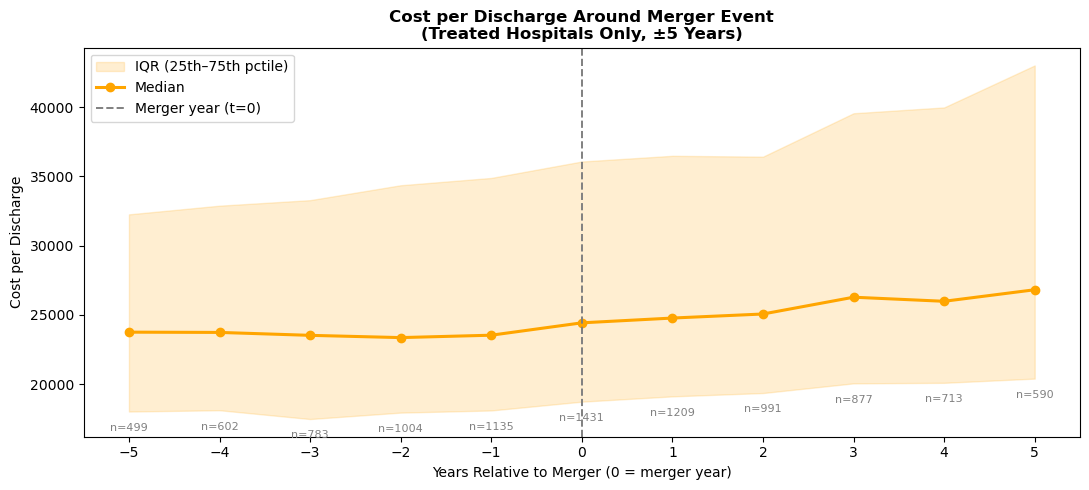

In [19]:
event_df = (
    plot_df[plot_df["treated"] == 1]
    .groupby("years_to_merger")["cost_per_discharge"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n="count",
    )
    .reset_index()
)

# Restrict to a ±5 year window around merger
event_df = event_df[event_df["years_to_merger"].between(-5, 5)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(
    event_df["years_to_merger"],
    event_df["q25"],
    event_df["q75"],
    alpha=0.18,
    color="orange",
    label="IQR (25th–75th pctile)",
)
ax.plot(
    event_df["years_to_merger"],
    event_df["median"],
    marker="o",
    markersize=6,
    linewidth=2.2,
    color="orange",
    label="Median",
)
ax.axvline(0, color="grey", linewidth=1.4, linestyle="--", label="Merger year (t=0)")

# Annotate hospital counts per year
for _, row in event_df.iterrows():
    ax.annotate(
        f"n={int(row['n'])}",
        xy=(row["years_to_merger"], row["q25"]),
        xytext=(0, -14),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="grey",
    )

ax.set_xlabel("Years Relative to Merger (0 = merger year)")
ax.set_ylabel("Cost per Discharge")
ax.set_title(
    "Cost per Discharge Around Merger Event\n(Treated Hospitals Only, ±5 Years)",
    fontweight="bold",
)
ax.set_xticks(range(-5, 6))
ax.legend()
plt.tight_layout()
plt.show()

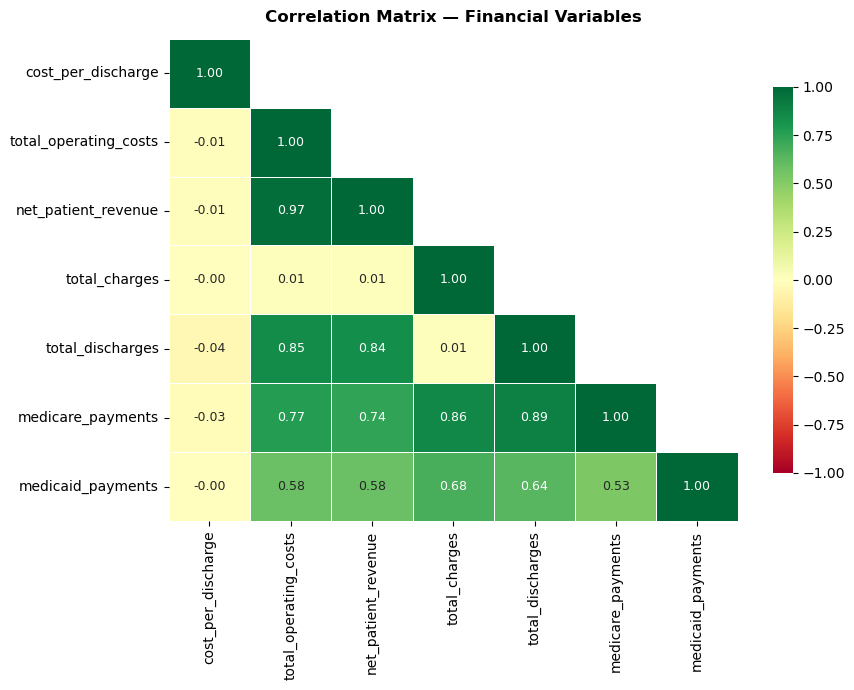

Saved: eda_04_correlation_matrix.png


In [ ]:
corr_cols = [
    "cost_per_discharge",
    "total_operating_costs",
    "net_patient_revenue",
    "total_charges",
    "total_discharges",
    "medicare_payments",
    "medicaid_payments",
]

corr = merged_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 9},
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Correlation Matrix — Financial Variables", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

                  hospital_years  unique_hospitals
merger_target               1261               932
merger_of_equals             435               406
bankruptcy                    19                18
system_exit                   50                42
system_split                  43                42


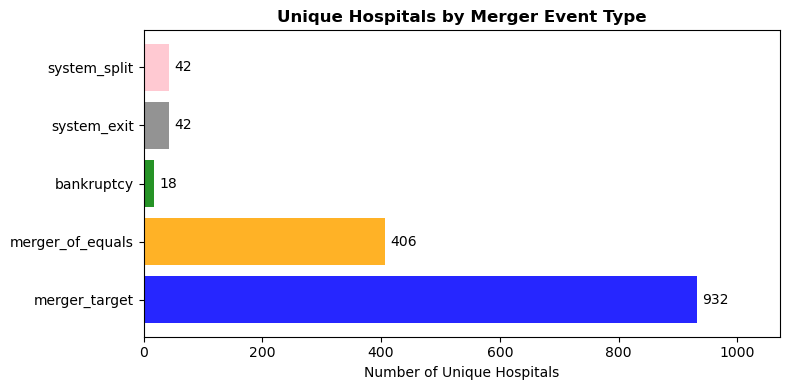

In [21]:
merger_type_cols = [
    "merger_target",
    "merger_of_equals",
    "bankruptcy",
    "system_exit",
    "system_split",
]

# count hospital-years with each flag = 1
type_counts = merged_df[merger_type_cols].sum().rename("hospital_years")

# count unique hospitals with each flag ever = 1
unique_hospitals = pd.Series(
    {col: merged_df[merged_df[col] == 1]["ccn"].nunique() for col in merger_type_cols},
    name="unique_hospitals",
)

print(
    pd.DataFrame(
        {"hospital_years": type_counts, "unique_hospitals": unique_hospitals}
    ).to_string()
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    merger_type_cols,
    unique_hospitals.values,
    color=["blue", "orange", "green", "grey", "pink"],
    alpha=0.85,
)
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel("Number of Unique Hospitals")
ax.set_title("Unique Hospitals by Merger Event Type", fontweight="bold")
ax.set_xlim(0, unique_hospitals.max() * 1.15)
plt.tight_layout()
plt.show()

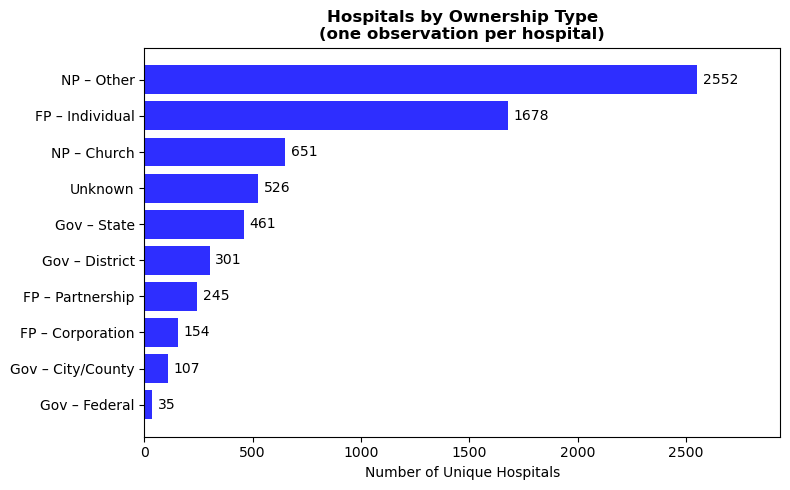

In [22]:
ownership_map = {
    "1": "NP – Church",
    "2": "NP – Other",
    "3": "NP – Other",
    "4": "FP – Individual",
    "5": "FP – Partnership",
    "6": "FP – Corporation",
    "7": "Gov – Federal",
    "8": "Gov – City/County",
    "9": "Gov – State",
    "10": "Gov – District",
}

merged_df["ownership_label"] = (
    merged_df["PRVDR_CTRL_TYPE_CD"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .map(ownership_map)
    .fillna("Unknown")
)

ownership_counts = (
    merged_df.drop_duplicates(subset="ccn")["ownership_label"]
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    ownership_counts.index, ownership_counts.values, color="blue", alpha=0.82
)
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel("Number of Unique Hospitals")
ax.set_title(
    "Hospitals by Ownership Type\n(one observation per hospital)", fontweight="bold"
)
ax.set_xlim(0, ownership_counts.max() * 1.15)
plt.tight_layout()
plt.show()